In [1]:
import pandas as pd

df = pd.read_csv('../data/india_cpi_raw.csv')
combined = df[df['Sector'] == 'Rural+Urban'].copy()
combined['Month'] = combined['Month'].replace('Marcrh', 'March')

month_map = {m: i+1 for i, m in enumerate(['January','February','March','April','May','June',
                                             'July','August','September','October','November','December'])}
combined['month_num'] = combined['Month'].map(month_map)
combined['date'] = pd.to_datetime(dict(year=combined['Year'], month=combined['month_num'], day=1))
combined = combined.sort_values('date').reset_index(drop=True)

# This time, keep the major category columns instead of just General index
categories = ['Food and beverages', 'Housing', 'Fuel and light', 'Clothing and footwear',
              'Transport and communication', 'Health', 'Education', 'Miscellaneous', 'General index']

cat_df = combined[['date'] + categories].copy()
print(cat_df.shape)
print(cat_df.head())
print(cat_df.isna().sum())

(124, 10)
        date  Food and beverages Housing  Fuel and light  \
0 2013-01-01               105.6   100.3           105.5   
1 2013-02-01               106.6   100.4           106.0   
2 2013-03-01               106.9   100.4           106.1   
3 2013-04-01               107.7   100.5           106.5   
4 2013-05-01               109.2   100.5           107.4   

   Clothing and footwear  Transport and communication  Health  Education  \
0                  106.2                        103.2   104.0      103.6   
1                  106.8                        104.2   104.5      103.9   
2                  107.3                        105.1   104.9      104.0   
3                  107.9                        104.7   105.3      105.0   
4                  108.5                        104.0   105.9      105.6   

   Miscellaneous  General index  
0          103.9          104.6  
1          104.4          105.3  
2          104.7          105.5  
3          104.8          106.1  
4 

In [2]:
# Check Housing specifically - it likely has a longer NA period (India's CPI methodology 
# didn't compute Housing index for the very first months after the 2012 base year rebase)
print("Housing missing dates:")
print(cat_df[cat_df['Housing'].isna()]['date'].tolist())

# Check all other categories
for col in categories:
    missing_dates = cat_df[cat_df[col].isna()]['date'].dt.strftime('%Y-%m').tolist()
    if missing_dates:
        print(f"{col}: {missing_dates}")

Housing missing dates:
[Timestamp('2020-05-01 00:00:00')]
Food and beverages: ['2020-05']
Housing: ['2020-05']
Fuel and light: ['2020-05']
Clothing and footwear: ['2020-04', '2020-05']
Transport and communication: ['2020-04', '2020-05']
Health: ['2020-05']
Education: ['2020-04', '2020-05']
Miscellaneous: ['2020-04', '2020-05']
General index: ['2020-04', '2020-05']


In [3]:
# Reindex to full continuous months first (in case any category has a different gap pattern)
full_range = pd.date_range(cat_df['date'].min(), cat_df['date'].max(), freq='MS')
cat_df = cat_df.set_index('date').reindex(full_range).rename_axis('date').reset_index()

# Interpolate all category columns
for col in categories:
    cat_df[col] = cat_df[col].interpolate(method='linear')

print("Remaining missing values:\n", cat_df.isna().sum())
cat_df.to_csv('../data/india_cpi_categories_clean.csv', index=False)
print("\nSaved:", cat_df.shape)

TypeError: Cannot interpolate with str dtype

In [4]:
print(cat_df.dtypes)

date                           datetime64[us]
Food and beverages                    float64
Housing                                   str
Fuel and light                        float64
Clothing and footwear                 float64
Transport and communication           float64
Health                                float64
Education                             float64
Miscellaneous                         float64
General index                         float64
dtype: object


In [5]:
print(cat_df['Housing'].unique())

<StringArray>
['100.3', '100.4', '100.5', '106.6', '107.7', '108.9', '109.7', '110.5',
 '111.1', '110.7',
 ...
 '167.8',   '169', '169.5', '171.2', '171.8', '170.7', '172.1', '173.5',
 '175.2', '175.6']
Length: 116, dtype: str


In [6]:
non_numeric = cat_df[pd.to_numeric(cat_df['Housing'], errors='coerce').isna() & cat_df['Housing'].notna()]
print(non_numeric[['date', 'Housing']])


Empty DataFrame
Columns: [date, Housing]
Index: []


In [7]:
cat_df['Housing'] = pd.to_numeric(cat_df['Housing'], errors='coerce')
print(cat_df['Housing'].dtype)
print("Missing:", cat_df['Housing'].isna().sum())
print(cat_df[cat_df['Housing'].isna()]['date'].tolist())

float64
Missing: 2
[Timestamp('2019-04-01 00:00:00'), Timestamp('2020-05-01 00:00:00')]


In [8]:
for col in categories:
    cat_df[col] = pd.to_numeric(cat_df[col], errors='coerce')  # safety net for all columns
    cat_df[col] = cat_df[col].interpolate(method='linear')

print("Remaining missing values:\n", cat_df.isna().sum())
cat_df.to_csv('../data/india_cpi_categories_clean.csv', index=False)
print("\nSaved:", cat_df.shape)

Remaining missing values:
 date                           0
Food and beverages             0
Housing                        0
Fuel and light                 0
Clothing and footwear          0
Transport and communication    0
Health                         0
Education                      0
Miscellaneous                  0
General index                  0
dtype: int64

Saved: (125, 10)


Calculate YoY inflation

In [9]:
inflation_df = cat_df[['date']].copy()
for col in categories:
    inflation_df[col] = cat_df[col].pct_change(12) * 100

inflation_df = inflation_df.dropna().reset_index(drop=True)
print(inflation_df.tail(10))

          date  Food and beverages   Housing  Fuel and light  \
103 2022-08-01            7.500000  4.256632        9.963100   
104 2022-09-01            8.414634  4.565083       10.393604   
105 2022-10-01            7.096005  4.645477        9.926918   
106 2022-11-01            5.067767  4.628502       10.616229   
107 2022-12-01            4.577883  4.467564       10.907983   
108 2023-01-01            6.189904  4.620061       10.840438   
109 2023-02-01            6.498195  4.833837        9.897405   
110 2023-03-01            5.106888  4.960678        8.791866   
111 2023-04-01            4.156909  4.910180        5.516841   
112 2023-05-01            3.346797  4.835821        4.696449   

     Clothing and footwear  Transport and communication    Health  Education  \
103               9.375000                     5.129870  4.988124   5.189255   
104              10.165340                     5.389610  5.581948   5.742211   
105              10.164334                     4.624277

Plot all category inflation rate together


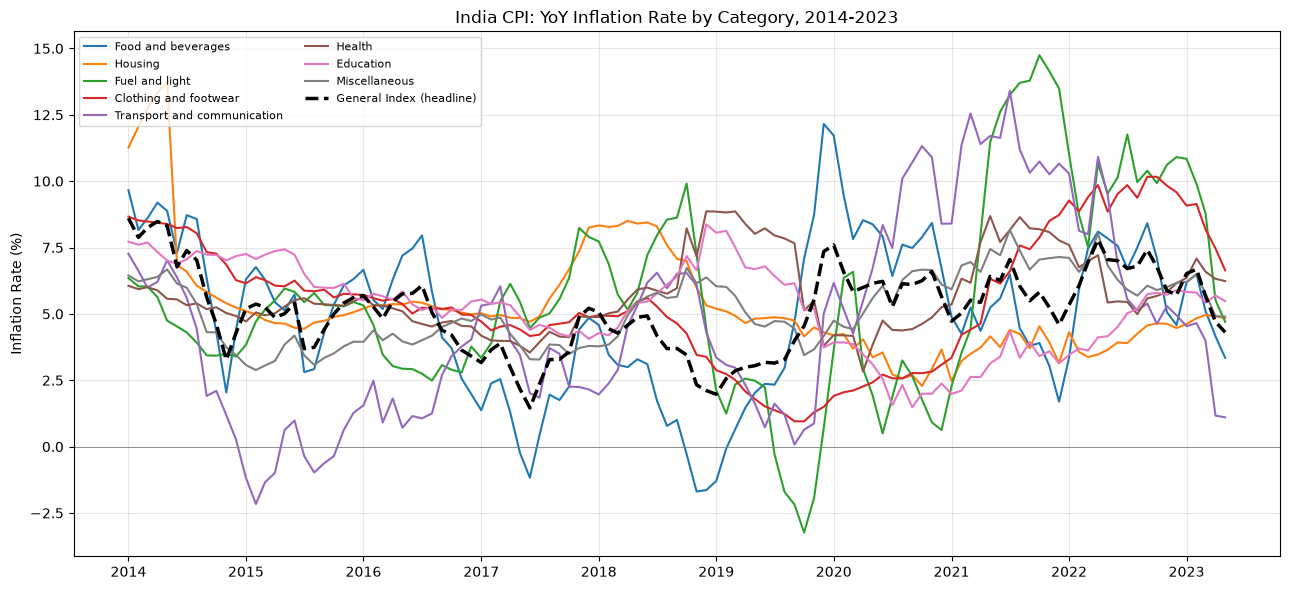

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(13,6))
colors = plt.cm.tab10.colors
for i, col in enumerate([c for c in categories if c != 'General index']):
    ax.plot(inflation_df['date'], inflation_df[col], label=col, linewidth=1.5, color=colors[i])

ax.plot(inflation_df['date'], inflation_df['General index'], label='General Index (headline)', 
        color='black', linewidth=2.5, linestyle='--')
ax.axhline(0, color='gray', linewidth=0.6)
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.set_title('India CPI: YoY Inflation Rate by Category, 2014-2023')
ax.set_ylabel('Inflation Rate (%)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/category_inflation_plot.png', dpi=120)
plt.show()

Quantify which category drove 2022 peak

In [11]:
# Find each category's peak inflation rate and when it occurred, within the 2022 spike window
spike_window = inflation_df[(inflation_df['date'] >= '2022-01-01') & (inflation_df['date'] <= '2022-12-31')]

peak_summary = []
for col in [c for c in categories if c != 'General index']:
    peak_val = spike_window[col].max()
    peak_date = spike_window.loc[spike_window[col].idxmax(), 'date']
    peak_summary.append({'category': col, 'peak_inflation_2022': round(peak_val,2), 'peak_month': peak_date.strftime('%Y-%m')})

peak_df = pd.DataFrame(peak_summary).sort_values('peak_inflation_2022', ascending=False)
print(peak_df)

                      category  peak_inflation_2022 peak_month
2               Fuel and light                11.76    2022-07
4  Transport and communication                10.91    2022-04
3        Clothing and footwear                10.17    2022-09
0           Food and beverages                 8.41    2022-09
7                Miscellaneous                 8.03    2022-04
5                       Health                 7.60    2022-01
6                    Education                 5.90    2022-12
1                      Housing                 4.65    2022-10


Rural vs Urban Comparison

In [12]:
rural = df[df['Sector'] == 'Rural'].copy()
urban = df[df['Sector'] == 'Urban'].copy()

for d, name in [(rural, 'Rural'), (urban, 'Urban')]:
    d['Month'] = d['Month'].replace('Marcrh', 'March')
    d['month_num'] = d['Month'].map(month_map)
    d['date'] = pd.to_datetime(dict(year=d['Year'], month=d['month_num'], day=1))
    d.sort_values('date', inplace=True)

rural_cpi = rural[['date','General index']].rename(columns={'General index':'cpi_rural'})
urban_cpi = urban[['date','General index']].rename(columns={'General index':'cpi_urban'})

sector_compare = rural_cpi.merge(urban_cpi, on='date', how='outer').sort_values('date').reset_index(drop=True)

full_range = pd.date_range(sector_compare['date'].min(), sector_compare['date'].max(), freq='MS')
sector_compare = sector_compare.set_index('date').reindex(full_range).rename_axis('date').reset_index()

for col in ['cpi_rural','cpi_urban']:
    sector_compare[col] = pd.to_numeric(sector_compare[col], errors='coerce')
    sector_compare[col] = sector_compare[col].interpolate(method='linear')

sector_compare['yoy_rural'] = sector_compare['cpi_rural'].pct_change(12)*100
sector_compare['yoy_urban'] = sector_compare['cpi_urban'].pct_change(12)*100

print(sector_compare.isna().sum())
print(sector_compare.tail())

date          0
cpi_rural     0
cpi_urban     0
yoy_rural    12
yoy_urban    12
dtype: int64
          date  cpi_rural  cpi_urban  yoy_rural  yoy_urban
120 2023-01-01      177.8      174.9   6.850962   6.000000
121 2023-02-01      178.0      176.3   6.778644   6.525680
122 2023-03-01      178.0      176.3   5.512745   5.885886
123 2023-04-01      178.8      177.4   4.683841   4.846336
124 2023-05-01      179.8      178.2   4.231884   4.332553


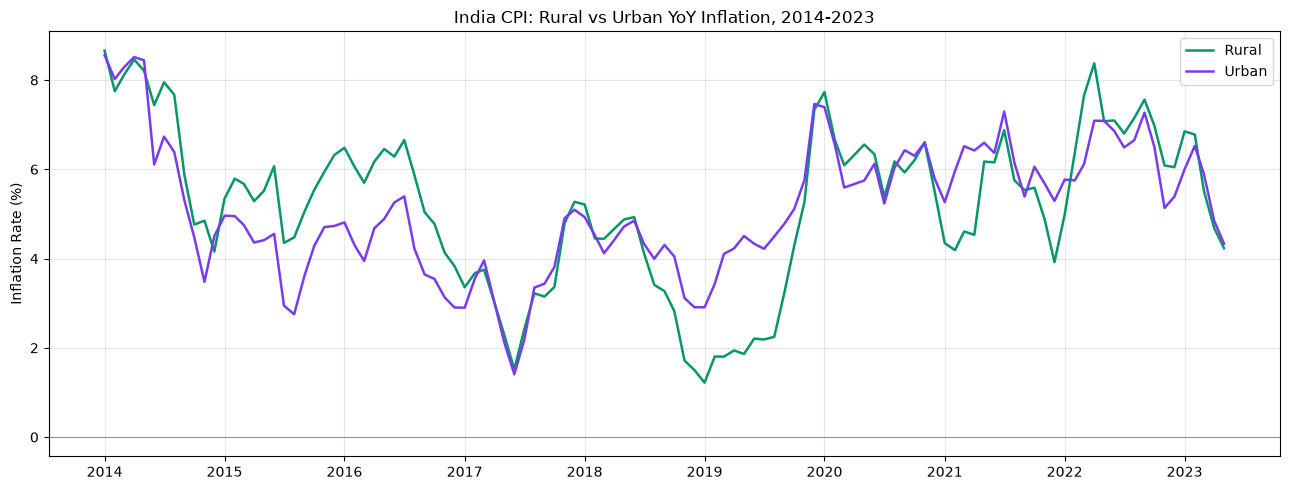

In [13]:
fig, ax = plt.subplots(figsize=(13,5))
ax.plot(sector_compare['date'], sector_compare['yoy_rural'], label='Rural', color='#059669', linewidth=1.8)
ax.plot(sector_compare['date'], sector_compare['yoy_urban'], label='Urban', color='#7c3aed', linewidth=1.8)
ax.axhline(0, color='gray', linewidth=0.6)
ax.legend()
ax.set_title('India CPI: Rural vs Urban YoY Inflation, 2014-2023')
ax.set_ylabel('Inflation Rate (%)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/rural_vs_urban_inflation_plot.png', dpi=120)
plt.show()